# [LangGraph](https://langchain-ai.github.io/langgraph/concepts/why-langgraph/)
- LangGraph는 LLM을 사용하여 상태를 유지하고 여러 에이전트를 포함한 애플리케이션을 쉽게 만들 수 있도록 도와줍니다.
- 이 도구는 LangChain의 기능을 확장하여, 복잡한 에이전트 런타임 개발에 필수적인 순환 그래프를 만들고 관리할 수 있는 기능을 추가합니다.
- LangGraph의 핵심 개념에는 그래프 구조, 상태 관리 및 조정이 포함됩니다.

## LangGraph의 핵심 구성요소

-  Node (노드): 실제 작업을 수행하는 단위
    - 질문 분석, 답변 생성, 검색 등의 구체적인 작업
-  Edge (간선): 노드들을 순차적으로 연결
    - 데이터가 흐르는 기본 경로
- Conditional Edge: 조건에 따라 다른 경로로 분기
    - "정보가 충분한가?" 같은 판단 후 YES/NO로 갈라짐
-  State (상태): 모든 노드가 공유하는 데이터 저장소
    - 질문, 수집된 정보, 처리 상태 등을 계속 저장하고 업데이트

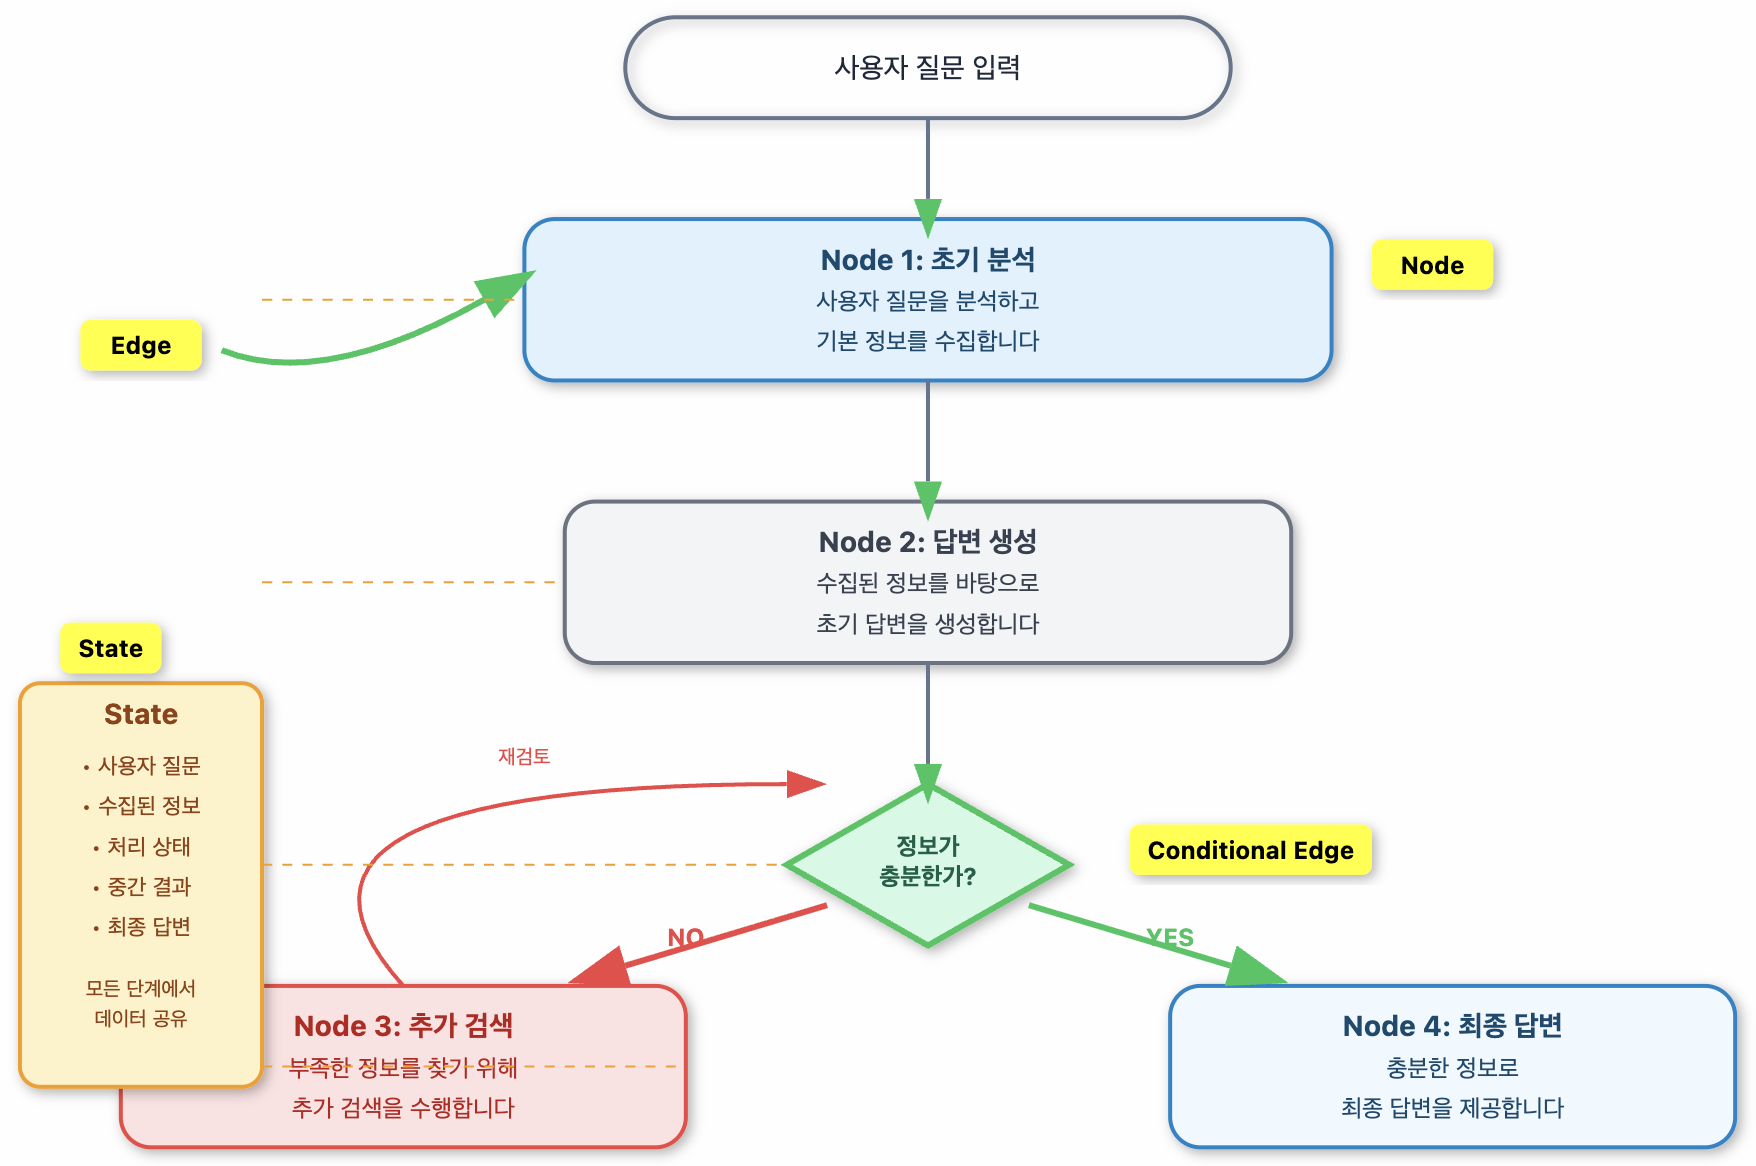

# LangGraph with conditional edge 예제

## 1단계: 확장된 상태 정의

In [1]:
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

class StudyState(TypedDict):
    """
    학습 도우미에서 사용할 상태
    """
    messages: Annotated[list, add_messages] # 챗팅 메세지 이력데이터 
    question_type: str  # 질문 유형 저장
    difficulty_level: str  # 난이도 저장

## 2단계: 각 유형별 응답 노드들

### 기초 개념을 쉽게 설명하는 노드

In [2]:
from langchain_core.messages import SystemMessage
from langchain_ollama.chat_models import ChatOllama 

def basic_explainer(state: StudyState):
    """기초 개념을 쉽게 설명하는 노드"""
    llm = ChatOllama(
        model="gemma3:4b",      # 이미 다운로드된 모델명 
        temperature=0.9,
        top_p=0.9,
        num_predict=512,
        keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
    )
    
    system_prompt = SystemMessage(content="""
    당신은 친근한 초보자 전용 선생님입니다. 
    - 복잡한 용어는 피하고 쉬운 말로 설명하세요
    - 일상생활 비유를 많이 사용하세요
    - 단계별로 차근차근 설명하세요
    - 격려하는 말을 포함하세요
    """)
    
    messages = [system_prompt] + state["messages"]
    response = llm.invoke(messages)
    
    print("기초 설명 모드로 답변 생성!")
    return {"messages": [response]} # add_messages()함수에 의해서 기존 이력메세지에 마지막 부분에 response 추가됨 
    

In [3]:
result = basic_explainer({
    "messages":["LLM이 뭐야?"]
})

기초 설명 모드로 답변 생성!


In [4]:
print(result['messages'][-1].content)

안녕! 궁금증을 해결해 줄 수 있어서 너무 기뻐! LLM이 뭔지 궁금하다고 하셨죠? 아주 좋은 질문이야. 쉽게 설명해 줄게요.

**LLM은 '대화형 인공지능'이라고 생각하면 돼.** 마치 내가 너랑 이야기하는 똑똑한 친구 같은 존재라고 보면 더 이해하기 쉬울 거야.

좀 더 자세히 설명하자면, LLM은 엄청나게 많은 책, 기사, 웹페이지 같은 글들을 읽고 학습한 인공지능 모델이야. 마치 네가 수백 권의 책을 읽고 시험을 보는 것과 비슷하지?

**이 모델들은 이렇게 할 수 있어:**

*   **질문에 답하기:** 네가 궁금한 것을 물어보면, 학습한 내용을 바탕으로 그에 대한 답을 찾아줘. 예를 들어 "고양이는 어떻게 돼지처럼 꿀꿀거리지?" 라고 물어보면, "고양이는 짖거나 야옹거리는데, 돼지는 꿀꿀거려. 둘은 소리가 다르다고 생각하면 돼!" 라고 대답해 줄 거야.
*   **글쓰기:** 네가 "고양이에 대한 짧은 이야기를 써줘" 라고 하면, 고양이에 대한 이야기를 만들어 줘. 물론, 내가 진짜 창의적인 작가처럼 멋진 이야기를 써주는 건 아니지만, 기본적인 문장 구조를 이해하고 글을 쓸 수 있단 말이야.
*   **번역하기:** 다른 언어로 된 글을 한국어로 번역하거나, 그 반대도 할 수 있어.
*   **아이디어 떠올리기:** 네가 "새로운 사업 아이템을 생각해 줘" 라고 하면, 다양한 아이디어를 제시해 줄 수도 있어.

**핵심은 LLM이 '학습'했다는 거야.** 엄청 많은 데이터를 통해 패턴을 파악하고, 그 패턴을 바탕으로 새로운 정보를 생성하거나 질문에 답하는 거지. 마치 네가 공부해서 시험을 잘 보는 것과 비슷하다고 생각하면 돼.

**쉽게 비유하자면:** LLM은 거대한 '지식 앨범'이라고 생각하면 돼. 이 앨범에는 세상의 거의 모든 정보가 담겨 있고, 네가 어떤 질문을 하든 그 질문에 맞는 페이지를 찾아내서 답을 알려주는 거야.

**걱정 마!** LLM은 아직 완벽하지 않아. 가끔 엉뚱한 답을 하거나


### 실습 예제를 제공하는 노드

In [5]:
def practice_provider(state: StudyState):
    """실습 예제를 제공하는 노드"""
    llm = ChatOllama(
        model="gemma3:4b",      # 이미 다운로드된 모델명 
        temperature=0.9,
        top_p=0.9,
        num_predict=512,
        keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
    )
    
    system_prompt = SystemMessage(content="""
    당신은 실습 위주의 코딩 선생님입니다.
    - 구체적이고 실행 가능한 코드 예제를 제공하세요
    - 주석을 자세히 달아주세요
    - 단계별로 실습할 수 있게 나누어주세요
    - 왜 이렇게 작성했는지 이유를 설명해주세요
    """)
    
    messages = [system_prompt] + state["messages"]
    response = llm.invoke(messages)
    
    print("실습 예제 모드로 답변 생성!")
    return {"messages": [response]} # add_messages()함수에 의해서 기존 이력메세지에 마지막 부분에 response 추가됨

In [6]:
result = practice_provider({
    "messages":["파이썬으로 계산기 만드는 예제 코드 보여줘"]
})

실습 예제 모드로 답변 생성!


In [7]:
print(result['messages'][-1].content)

## 파이썬 계산기 예제 코드 (실습 위주)

안녕하세요! 파이썬으로 간단한 계산기를 만들어보도록 하겠습니다. 이 예제는 코딩 초보자도 쉽게 따라 할 수 있도록 단계별로 구성되었으며, 각 단계별 코드와 함께 주석을 상세하게 달아 설명합니다. 또한, 왜 특정 코드를 사용했는지에 대한 이유도 함께 설명하여 이해도를 높입니다.

**목표:**

*   사용자로부터 두 개의 숫자와 연산자(+,-,*,/)를 입력받습니다.
*   입력받은 숫자와 연산자를 사용하여 계산을 수행합니다.
*   결과를 사용자에게 보여줍니다.

**단계 1: 사용자 입력 받기**

```python
# 사용자로부터 첫 번째 숫자 입력 받기
num1 = float(input("첫 번째 숫자를 입력하세요: "))

# 사용자로부터 두 번째 숫자 입력 받기
num2 = float(input("두 번째 숫자를 입력하세요: "))

# 사용자로부터 연산자 입력 받기
operator = input("연산자 (+, -, *, /)를 입력하세요: ")
```

**이유:**

*   `input()` 함수를 사용하여 사용자로부터 입력을 받습니다.
*   `float()` 함수를 사용하여 입력받은 문자열을 실수(float)로 변환합니다.  실수로 변환하는 이유는 정수(int)만 처리할 수 있는 연산을 수행하기 위함입니다.
*   연산자를 문자열 형태로 받습니다.

**단계 2: 계산 수행**

```python
# 입력받은 연산자에 따라 계산 수행
if operator == '+':
    result = num1 + num2
elif operator == '-':
    result = num1 - num2
elif operator == '*':
    result = num1 * num2
elif operator == '/':
    # 0으로 나누는 경우 예외 처리
    if num2 == 0:
        print("오류: 0으로 나눌 수 없습니다.")
        result = None  #

### 심화 내용을 분석해서 설명하는 노드

In [8]:
def advanced_analyzer(state: StudyState):
    """심화 내용을 분석해서 설명하는 노드"""
    llm = ChatOllama(
        model="gemma3:4b",      # 이미 다운로드된 모델명 
        temperature=0.9,
        top_p=0.9,
        num_predict=512,
        keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
    )
    
    system_prompt = SystemMessage(content="""
    당신은 전문적인 기술 분석가입니다.
    - 깊이 있는 기술적 설명을 제공하세요
    - 원리와 동작 방식을 상세히 설명하세요
    - 장단점과 한계점도 함께 언급하세요
    - 관련 기술이나 개념과의 연관성을 설명하세요
    """)
    
    messages = [system_prompt] + state["messages"]
    response = llm.invoke(messages)
    
    print("심화 분석 모드로 답변 생성!")
    return {"messages": [response]} # add_messages()함수에 의해서 기존 이력메세지에 마지막 부분에 response 추가됨

In [9]:
result = advanced_analyzer({
    "messages":["파이썬의 GIL은 왜 존재하고 어떤 원리로 동작하나요?"]
})

심화 분석 모드로 답변 생성!


In [10]:
print(result['messages'][-1].content)

## 파이썬 GIL (Global Interpreter Lock)의 원리와 동작 방식, 그리고 장단점

파이썬의 GIL은 파이썬 인터프리터가 한 번에 하나의 스레드로만 실행되도록 하는 메커니즘입니다. 이는 파이썬 구현의 핵심적인 부분이며, 성능 및 동시성 측면에서 중요한 영향을 미칩니다. 

**1. GIL의 필요성: 파이썬 인터프리터의 설계 철학**

* **C 확장 모듈과의 호환성:** 파이썬은 C로 작성된 확장 모듈과 긴밀하게 연동됩니다. C 코드는 파이썬 인터프리터의 내부 상태를 직접 변경할 수 있으며, GIL이 없다면 이러한 C 코드가 파이썬 스레드 간에 경쟁하여 예측 불가능하고 오류가 발생하기 쉽습니다. GIL은 C 확장 모듈의 안전한 실행을 보장하기 위해 도입되었습니다.
* **메모리 관리의 단순화:** GIL은 파이썬 객체의 메모리 관리를 단순화합니다. C 확장 모듈이 파이썬 객체의 메모리를 직접 조작할 때 발생하는 잠재적인 문제를 방지합니다.
* **가상 기계 (VM) 구현의 용이성:** 파이썬 인터프리터는 가상 기계와 유사한 방식으로 동작합니다. GIL은 인터프리터의 내부 상태를 일관성 있게 유지하고 예측 가능한 실행을 보장하는 데 도움을 줍니다.

**2. GIL의 동작 방식**

* **단일 스레드 실행:** GIL은 파이썬 인터프리터 내부에서 C 런타임 환경을 관리합니다. GIL은 특정 시점에 단 하나의 스레드만 실행되도록 제한합니다. 다른 스레드가 파이썬 코드 실행을 시도하면 GIL이 획득될 때까지 기다려야 합니다.
* **GIL 획득 및 해제:**
    * 스레드가 파이썬 코드 실행을 시작하면 GIL을 획득합니다.
    * 스레드가 GIL을 획득한 동안 다른 스레드는 실행될 수 없습니다.
    * 스레드가 I/O 작업 (예: 네트워크 요청, 파일 읽기/쓰기) 또는 다른 Blocking 작업에 의해 일시 중단되면 GIL이 해제됩니다.
    * 다른 스레드가 GIL을 획득하여 실행을 계속합니다.
*


### 일반적인 도움을 제공하는 노드

In [11]:
def general_helper(state: StudyState):
    """일반적인 도움을 제공하는 노드"""
    llm = ChatOllama(
        model="gemma3:4b",      # 이미 다운로드된 모델명 
        temperature=0.9,
        top_p=0.9,
        num_predict=512,
        keep_alive="10m"        # 로컬PC에서 모델이 메모리에 유지되는 시간 
    )
    
    system_prompt = SystemMessage(content="""
    당신은 균형잡힌 학습 도우미입니다.
    - 적절한 수준에서 설명하세요
    - 필요시 예제와 이론을 적절히 섞어주세요
    - 추가 학습 방향을 제시해주세요
    """)
    
    messages = [system_prompt] + state["messages"]
    response = llm.invoke(messages)
    
    print("균형잡힌 답변 모드로 답변 생성!")
    return {"messages": [response]} # add_messages()함수에 의해서 기존 이력메세지에 마지막 부분에 response 추가됨

In [12]:
result = general_helper({
    "messages":["파이썬 공부하는 좋은 방법이 있을까요?"]
})

균형잡힌 답변 모드로 답변 생성!


In [13]:
print(result['messages'][-1].content)

네, 파이썬 공부하는 좋은 방법은 여러 가지가 있습니다. 개인의 학습 스타일과 목표에 맞춰 체계적으로 접근하는 것이 중요합니다. 제가 몇 가지 방법을 단계별로 나누어 설명하고, 각 단계별 추가 학습 방향도 제시해 드릴게요.

**1. 기초 다지기 (1~2주)**

*   **온라인 튜토리얼 활용:**
    *   **점프 투 파이썬:** 파이썬 입문자를 위한 가장 유명하고 훌륭한 무료 온라인 교재입니다. 기본적인 문법, 자료형, 제어문 등을 차근차근 학습할 수 있습니다. ([https://wikidocs.net/python](https://wikidocs.net/python))
    *   **Codecademy:** 인터랙티브한 방식으로 파이썬을 배울 수 있는 온라인 플랫폼입니다. 직접 코드를 작성하고 실행하면서 실력을 키울 수 있습니다. ([https://www.codecademy.com/learn/learn-python-3](https://www.codecademy.com/learn/learn-python-3))
    *   **Google's Python Class:** Google에서 제공하는 파이썬 기초 강좌입니다. 파이썬 문법과 함께 기본적인 알고리즘 문제 해결 방법을 익힐 수 있습니다. ([https://developers.google.com/edu/python](https://developers.google.com/edu/python))
*   **기본 문법 학습:**
    *   변수, 자료형 (정수, 실수, 문자열, 불리언), 연산자, 조건문 (if, else, elif), 반복문 (for, while) 등
    *   예시:
        ```python
        # 변수 선언 및 할당
        name = "Alice"
        age = 30

        # 조건문
        if age >= 18:
            print("성인입니다.")
        else:
            pri

## 3단계: 질문 분석 노드

In [14]:
def analyze_question(state: StudyState):
    """
    사용자 질문을 분석해서 유형을 판단하는 노드
    """
    user_message = state["messages"][-1].content.lower()
    
    # 간단한 키워드 기반 분석 (실제로는 더 정교한 NLP 사용 가능)
    if any(keyword in user_message for keyword in ["처음", "초보", "기초", "시작", "뭐야", "무엇"]):
        question_type = "basic"
        difficulty = "beginner"
        print("질문 분석: 기초 개념 질문")
        
    elif any(keyword in user_message for keyword in ["예제", "실습", "코드", "만들어", "구현"]):
        question_type = "practice"
        difficulty = "intermediate"
        print("질문 분석: 실습/예제 요청")
        
    elif any(keyword in user_message for keyword in ["심화", "고급", "원리", "왜", "어떻게"]):
        question_type = "advanced"
        difficulty = "advanced"
        print("질문 분석: 심화 개념 질문")
        
    else:
        question_type = "general"
        difficulty = "intermediate"
        print("질문 분석: 일반적인 질문")
    
    return {
        "question_type": question_type,
        "difficulty_level": difficulty
    }

In [15]:
from langchain_core.messages import HumanMessage

result = analyze_question({
    "messages": [HumanMessage(content="LangChain이 뭐야?")]
})

질문 분석: 기초 개념 질문


In [16]:
result

{'question_type': 'basic', 'difficulty_level': 'beginner'}

## 4단계: 조건부 라우팅 함수

In [17]:
def route_by_question_type(state: StudyState) -> str:
    """
    질문 유형에 따라 어떤 노드로 갈지 결정하는 함수
    이것이 바로 '조건부 엣지'의 핵심입니다!
    """
    question_type = state.get("question_type", "general")
    
    print(f"라우팅: {question_type} 유형 → ", end="")
    
    if question_type == "basic":
        print("기초 설명 노드로 이동")
        return "basic_explanation"
    elif question_type == "practice":
        print("실습 예제 노드로 이동")
        return "practice_examples"
    elif question_type == "advanced":
        print("심화 분석 노드로 이동")
        return "advanced_analysis"
    else:
        print("일반 도움 노드로 이동")
        return "general_help"

In [18]:
route_by_question_type(result)

라우팅: basic 유형 → 기초 설명 노드로 이동


'basic_explanation'

## 5단계: 조건부 그래프 구성

In [19]:
from langgraph.graph import StateGraph, END, START

def create_smart_study_assistant():
    """
    조건부 엣지가 있는 스마트 학습 도우미 그래프
    """
    ##################################################
    # 그래프를 생성할 객체 생성   
    ################################################## 
    workflow = StateGraph(StudyState)
    
    ##################################################
    # 모든 노드 추가
    ##################################################
    workflow.add_node("analyze", analyze_question)
    workflow.add_node("basic_explanation", basic_explainer)
    workflow.add_node("practice_examples", practice_provider)
    workflow.add_node("advanced_analysis", advanced_analyzer)
    workflow.add_node("general_help", general_helper)
    
    ##################################################
    # 모든 엣지 추가 
    ##################################################
    # 시작점: 질문 분석부터
    # workflow.set_entry_point("analyze")
    workflow.add_edge(START, "analyze")
    
    # 조건부 엣지: 분석 결과에 따라 분기
    workflow.add_conditional_edges(
        "analyze",  # 어떤 노드에서
        route_by_question_type,  # 어떤 함수로 결정하고
        {
            "basic_explanation": "basic_explanation",
            "practice_examples": "practice_examples", 
            "advanced_analysis": "advanced_analysis",
            "general_help": "general_help"
        }  # 가능한 다음 노드들
    )
    
    # 모든 응답 노드는 종료점
    # workflow.set_finish_point("basic_explanation")
    # workflow.set_finish_point("practice_examples")
    # workflow.set_finish_point("advanced_analysis")
    # workflow.set_finish_point("general_help")
    workflow.add_edge("basic_explanation", END)
    workflow.add_edge("practice_examples", END)
    workflow.add_edge("advanced_analysis", END)
    workflow.add_edge("general_help", END)

    ##################################################
    # 컴파일 -> 그래프 생성  
    ################################################## 
    return workflow.compile()

In [20]:
graph = create_smart_study_assistant()

## 6단계: 그래프 확인

```
시작
  |
  v
analyze
  |
  +-- advanced_analysis --> 종료
  |
  +-- basic_explanation --> 종료
  |
  +-- general_help --> 종료
  |
  +-- practice_examples --> 종료
```


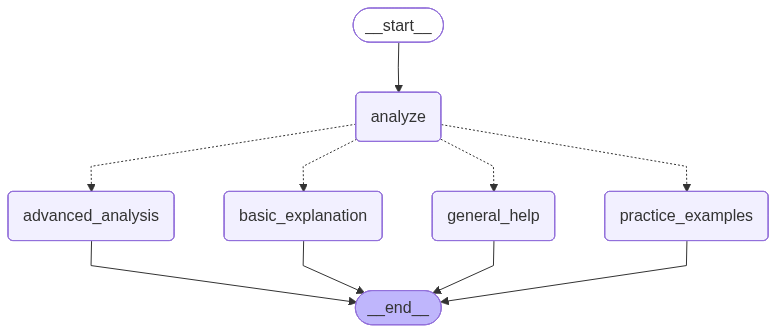

In [ ]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 7단계: 테스트

In [22]:
from langchain_core.messages import HumanMessage

result = graph.invoke({
    "messages": [HumanMessage(content="LangChain이 뭐야?")]
})

print(f"감지된 유형: {result.get('question_type', '미확인')}")
print(f"난이도: {result.get('difficulty_level', '미확인')}")


질문 분석: 기초 개념 질문
라우팅: basic 유형 → 기초 설명 노드로 이동
기초 설명 모드로 답변 생성!
감지된 유형: basic
난이도: beginner


In [23]:
print(f"답변: {result.get('messages')[-1].content}")

답변: 안녕하세요! 🤗 LangChain은 마치 레고 블록을 모아 멋진 작품을 만드는 것과 비슷해요. 복잡한 인공지능(AI) 기술을 쉽게 사용할 수 있도록 도와주는 도구 세트라고 생각하면 돼요.

**쉽게 말하면, LangChain은 AI 모델(예: ChatGPT)을 이용해서 더 똑똑하고 유용한 프로그램을 만들 수 있게 해주는 '조립 키트' 같아요.**

**왜 LangChain이 필요할까요?**

*   **ChatGPT는 똑똑하지만, 스스로 생각하는 건 아니에요.** ChatGPT는 우리가 던지는 질문에 답하거나, 주어진 글을 요약하는 등 '단순한 작업'은 잘해요. 하지만 복잡한 질문에 답하려면, 여러 단계의 과정을 거쳐야 하고, 외부 정보를 활용해야 할 수도 있어요.
*   **LangChain은 이런 복잡한 작업을 도와줘요.** 예를 들어, “오늘 날씨 알려줘”라는 질문을 받으면, LangChain은 다음과 같은 단계를 거쳐 답변을 만들어낼 수 있어요.
    1.  **질문을 이해해요:** “오늘 날씨”라는 핵심 내용을 파악하고, 어느 지역의 날씨를 알고 싶은지 확인해요.
    2.  **외부 정보 가져와요:** 날씨 API 같은 외부 정보를 가져와요. (예: “서울 날씨”를 검색)
    3.  **정보를 분석하고 결합해요:** 가져온 날씨 정보를 ChatGPT에 전달해서, “오늘 서울 날씨는…”와 같이 보기 좋게 만들어줘요.

**LangChain의 핵심 구성 요소:**

*   **체인(Chain):** 여러 단계를 연결해서 복잡한 작업을 수행하는 것들을 묶어 놓은 거예요. 마치 레고 블록을 연결해서 집을 만드는 것과 같아요.
*   **모델(Model):** ChatGPT 같은 AI 모델을 사용해서, 텍스트를 생성하거나 분석하는 역할을 해요.
*   **데이터 연결(Data Connection):** LangChain은 웹사이트, 문서, 데이터베이스 등 다양한 곳에서 정보를 가져올 수 있게 해줘요.
*   **에이전트(Agent):** Lan

In [24]:
# 각 유형별 테스트 질문들
test_cases = [
    ("기초", "파이썬이 뭐야? 처음 들어봐서 잘 모르겠어"), # 처음
    ("실습", "파이썬으로 계산기 만드는 예제 코드 보여줘"), # 예제, 코드
    ("심화", "파이썬의 GIL은 왜 존재하고 어떤 원리로 동작하나요?"), # 원리
    ("일반", "파이썬 공부하는 좋은 방법이 있을까요?")
]

for category, question in test_cases:
    print(f"\n[{category}] 질문: {question}")
    print("-" * 40)
    
    result = graph.invoke({
        "messages": [HumanMessage(content=question)]
    })
    
    print(f"감지된 유형: {result.get('question_type', '미확인')}")
    print(f"난이도: {result.get('difficulty_level', '미확인')}")
    print("="*50)



[기초] 질문: 파이썬이 뭐야? 처음 들어봐서 잘 모르겠어
----------------------------------------
질문 분석: 기초 개념 질문
라우팅: basic 유형 → 기초 설명 노드로 이동
기초 설명 모드로 답변 생성!
감지된 유형: basic
난이도: beginner

[실습] 질문: 파이썬으로 계산기 만드는 예제 코드 보여줘
----------------------------------------
질문 분석: 실습/예제 요청
라우팅: practice 유형 → 실습 예제 노드로 이동
실습 예제 모드로 답변 생성!
감지된 유형: practice
난이도: intermediate

[심화] 질문: 파이썬의 GIL은 왜 존재하고 어떤 원리로 동작하나요?
----------------------------------------
질문 분석: 심화 개념 질문
라우팅: advanced 유형 → 심화 분석 노드로 이동
심화 분석 모드로 답변 생성!
감지된 유형: advanced
난이도: advanced

[일반] 질문: 파이썬 공부하는 좋은 방법이 있을까요?
----------------------------------------
질문 분석: 일반적인 질문
라우팅: general 유형 → 일반 도움 노드로 이동
균형잡힌 답변 모드로 답변 생성!
감지된 유형: general
난이도: intermediate


## [Langsmith에서 확인](https://smith.langchain.com/)

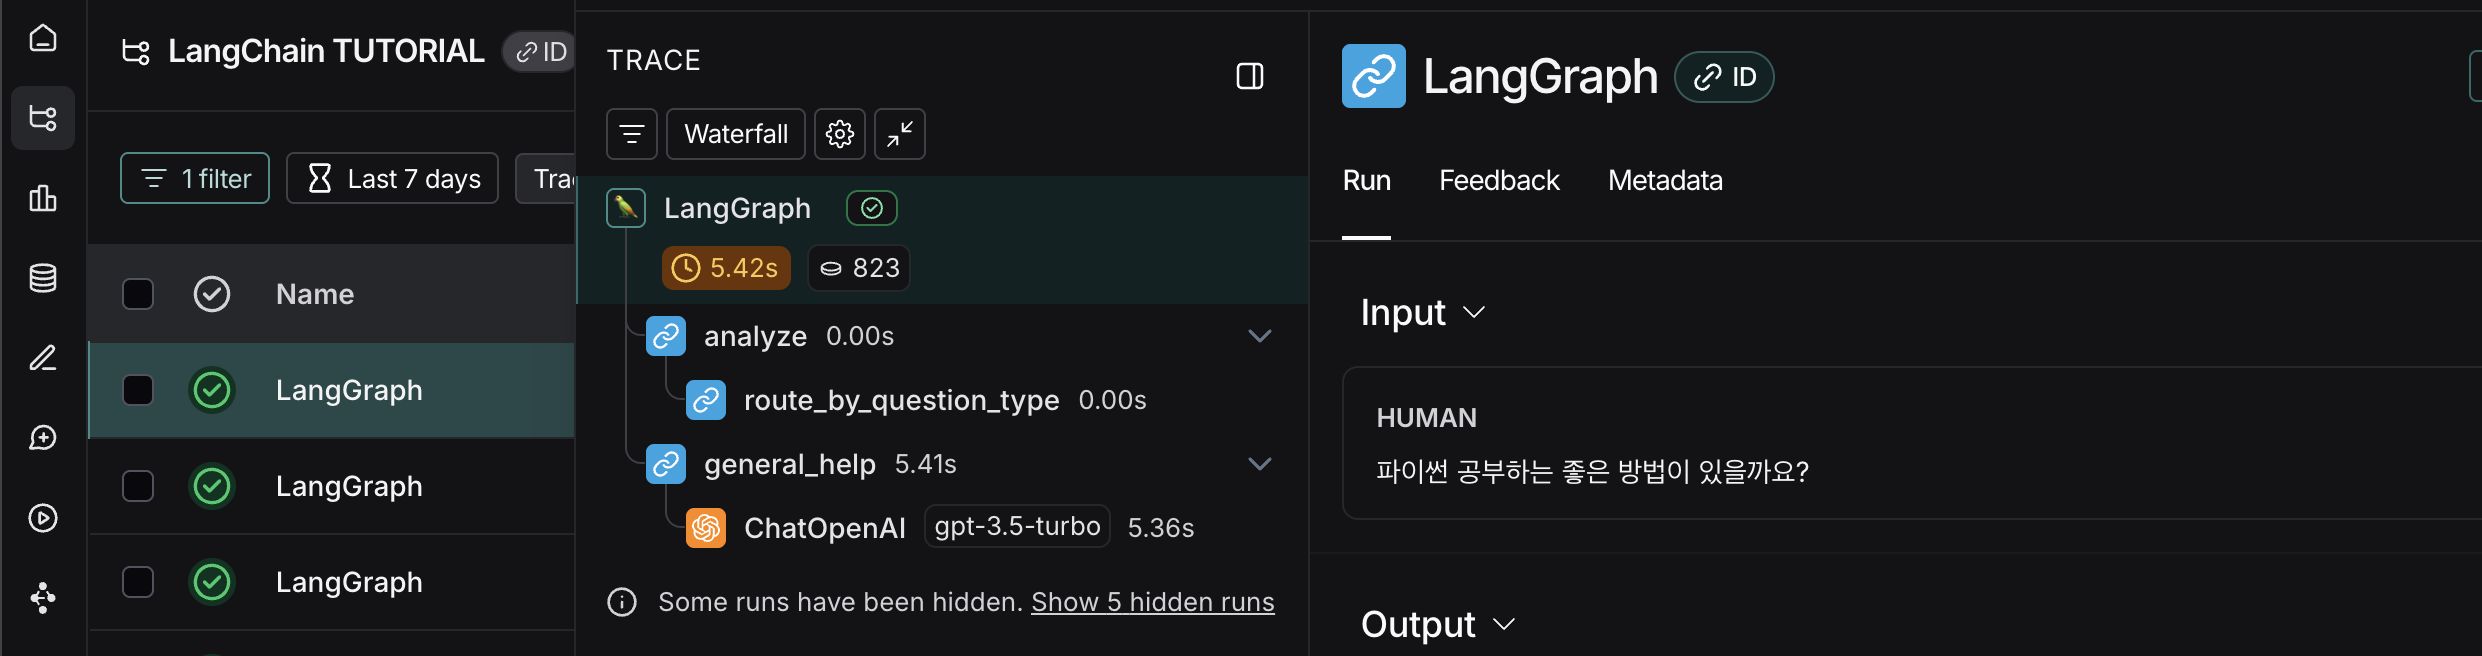